In [1]:
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import numpy as np
import pyuda
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit

In [2]:
### function for loading all the spectrometer channels, 5 in total
def getSpec(shotn, wl='linear'):
    if wl == 662:
        coeff = np.array([-8.003857638849921e-08, 0.008115909538641598, 656.594265617137])
    elif wl == 'linear':
        coeff = np.array([8.07716749e-3, 6.52544930e2])
    else:
        # wl=658
        coeff = np.array([-7.962860863439673e-08, 0.008153179395386338, 652.5690918688852])
    px = np.polyval(coeff, np.arange(1, 1341))
    client = pyuda.Client()
    time = client.get('/XSM/MSE/SPEC/CH00', shotn).time.data
    data = np.zeros((5,len(time),len(px)))
    for i in range(0, 5):
        data[i] = client.get('/XSM/MSE/SPEC/CH'+str(i).zfill(2), shotn).data
    return time, data, px


### define a bunch of functions that we can fit to the data depending on the
### number of peaks
### define the one gaussian
def gaussian(x, A, x0, sigma):
    return A * np.exp(-(x - x0)**2 / (2. * sigma**2))
def func1(x, A1, x01, s1):#, C):
    y = gaussian(x, A1, x01, s1)# + C
    return y
def func2(x, A1, x01, s1, A2, x02, s2):#, C):
    y = gaussian(x, A1, x01, s1) + gaussian(x, A2, x02, s2)# + C
    return y
def func3(x, A1, x01, s1, A2, x02, s2, A3, x03, s3):#, C):
    y = gaussian(x, A1, x01, s1) + gaussian(x, A2, x02, s2) + \
        gaussian(x, A3, x03, s3)# + C
    return y
def func4(x, A1, x01, s1, A2, x02, s2, A3, x03, s3, A4, x04, s4):#, C):
    y = gaussian(x, A1, x01, s1) + gaussian(x, A2, x02, s2) + \
        gaussian(x, A3, x03, s3) + gaussian(x, A4, x04, s4)# + C
    return y
def func5(x, A1, x01, s1, A2, x02, s2, A3, x03, s3, A4, x04, s4, A5, x05, s5):#, C):
    y = gaussian(x, A1, x01, s1) + gaussian(x, A2, x02, s2) + \
        gaussian(x, A3, x03, s3) + gaussian(x, A4, x04, s4) + \
        gaussian(x, A5, x05, s5)# + C
    return y
def func6(x, A1, x01, s1, A2, x02, s2, A3, x03, s3, A4, x04, s4, A5, x05, s5, A6, x06, s6):#, C):
    y = gaussian(x, A1, x01, s1) + gaussian(x, A2, x02, s2) + \
        gaussian(x, A3, x03, s3) + gaussian(x, A4, x04, s4) + \
        gaussian(x, A5, x05, s5) + gaussian(x, A6, x06, s6)# + C
    return y
def func7(x, A1, x01, s1, A2, x02, s2, A3, x03, s3, A4, x04, s4, A5, x05, s5, A6, x06, s6, A7, x07, s7):#, C):
    y = gaussian(x, A1, x01, s1) + gaussian(x, A2, x02, s2) + \
        gaussian(x, A3, x03, s3) + gaussian(x, A4, x04, s4) + \
        gaussian(x, A5, x05, s5) + gaussian(x, A6, x06, s6) + \
        gaussian(x, A7, x07, s7)# + C
    return y


def findNearest(arr, val):
    return np.abs(arr - val).argmin()

In [3]:
%matplotlib widget

In [16]:
### load the transmission curve of the two filters as provided by andover.
### if you're not on freia and don't have access to these files, let me know
filter = np.load('/home/sthoma/tokamak_inversion_routines/mastu/filterHSV.npz')
filter_15A = np.load('/home/sthoma/tokamak_inversion_routines/mastu/filterHSV_1.5A.npz')
filter_15B = np.load('/home/sthoma/tokamak_inversion_routines/mastu/filterHSV_1.5B.npz')
filter_andover = np.load('/home/sthoma/tokamak_inversion_routines/mastu/filterHSV_andover.npz')
filter_CCFE = np.load('/home/sthoma/tokamak_inversion_routines/mastu/filterHSV_andoverCCFE_adjusted.npz')


### example shot number
# shotn = 50738
# shotn = 50747
shotn = 51081
### wl='linear' is the correct calibration
spt, spd, wl = getSpec(shotn, wl='linear')

In [17]:
fHSV = interp1d(filter['wavelength'], filter['transmission'])
f_15A = interp1d(filter_15A['wavelength'], filter_15A['transmission'])
f_15B = interp1d(filter_15B['wavelength'], filter_15B['transmission'])
f_andover = interp1d(filter_andover['wavelength'], filter_andover['transmission'])
f_CCFE = interp1d(filter_CCFE['wavelength'], filter_CCFE['transmission'])

6030.867470806668 5.936562087099893 1.1321594030079636
6081.2272139529205 5.933406246189263 1.1329518999223922
5695.336829286003 6.455474138294883 1.226014056001362
5742.910655747287 6.452070388048705 1.2268636338521846
5907.430192478021 6.066642511612792 1.1142638835937089
5956.796737449898 6.063521210273564 1.1150112722480976
5849.994367013406 4.451040774974061 0.8744136765566424
5898.8579197944355 4.448673611588051 0.8750231742510524
7083.750053858807 5.730531300367982 1.0184001294718257
7142.936228390172 5.727597502702043 1.019081832440965


/tmp/ipykernel_1655/3859836274.py:73: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1, 1, figsize=(6,4), dpi=150)


8600.43008378866 6.581852680860875 1.1936752703668763
8672.288281535293 6.578472811850987 1.1944781283027366
10186.179375527694 7.568047378575352 1.3165217317242794
10271.283898107047 7.564173917392458 1.317398810604878
10747.611661527902 7.788838746934477 1.3916192258162663
10837.408395579665 7.784840239693051 1.3925440782276475
11874.028650014312 8.55010407753052 1.5229266256734961
11973.230400412162 8.545718887208235 1.5239421254538523
12858.149350629817 9.08966069548269 1.5792513526914145
12965.572178369945 9.08500601798796 1.5803043700576511
15330.864416845454 11.366316917990568 2.0724344625831206
15458.942371845491 11.360466918240176 2.0738211664626482
11475.753120521033 9.797906464988515 1.8616365753523605
11571.599617843189 9.792742802186828 1.862922268923681


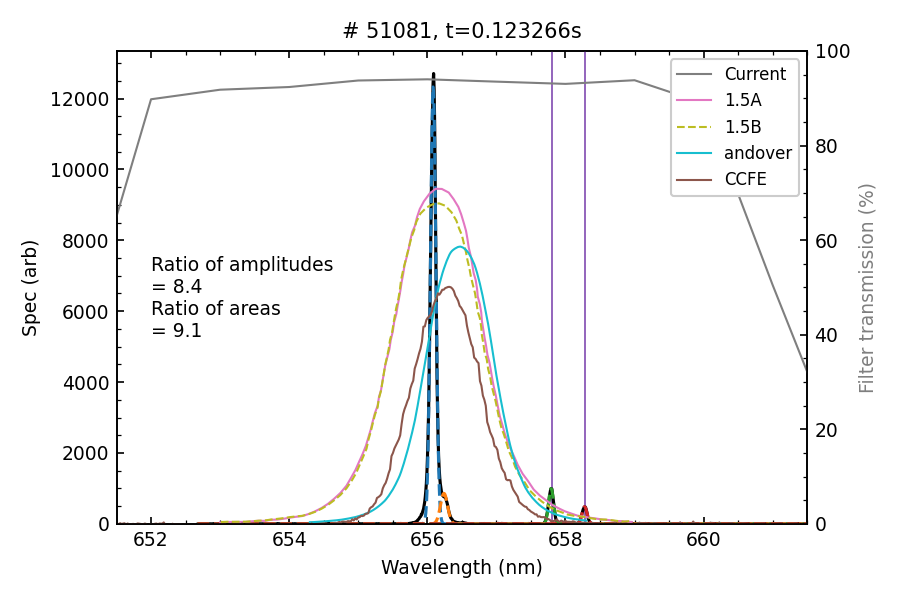

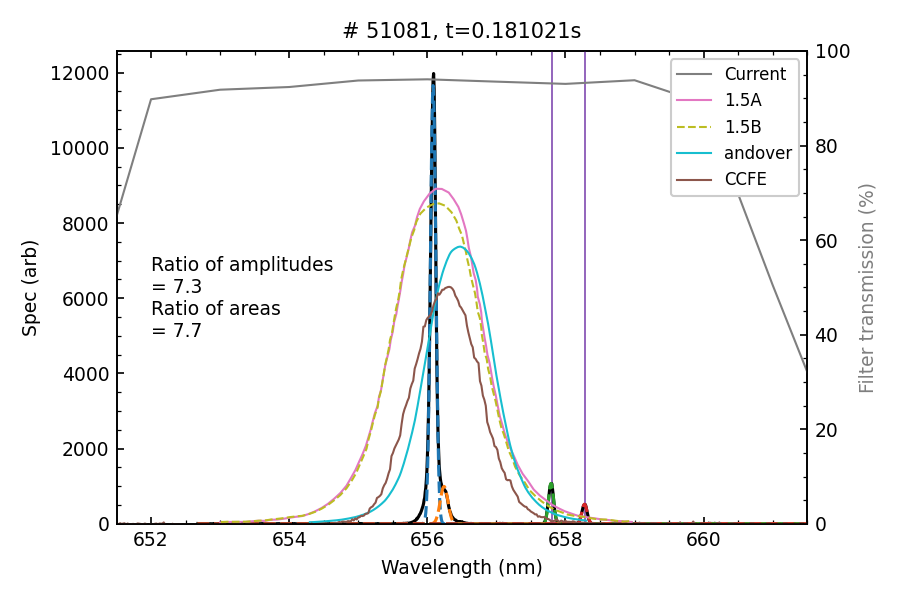

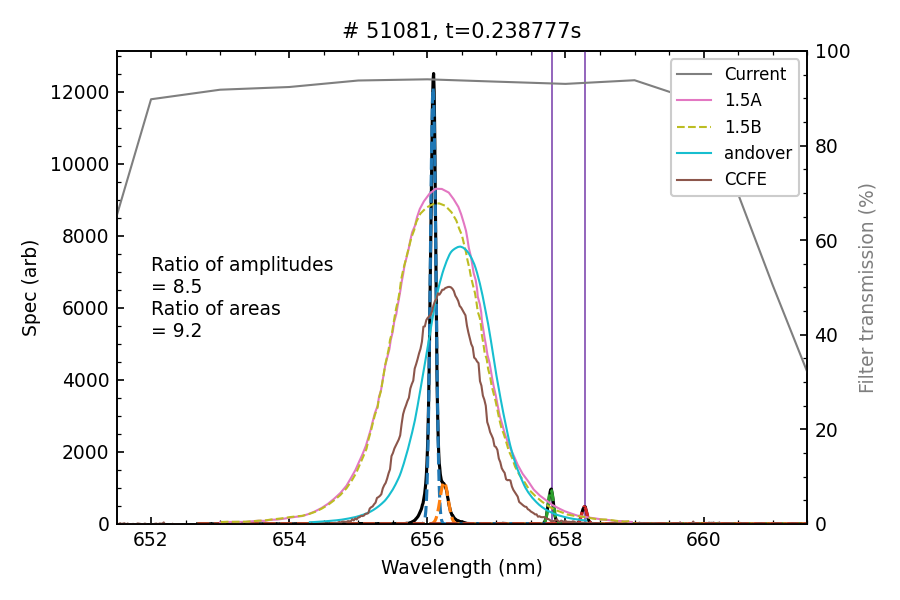

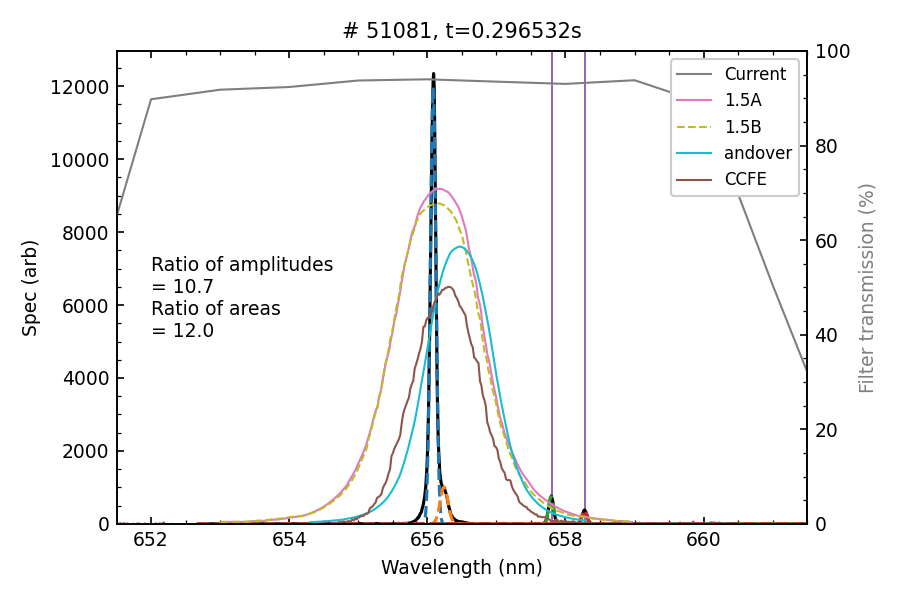

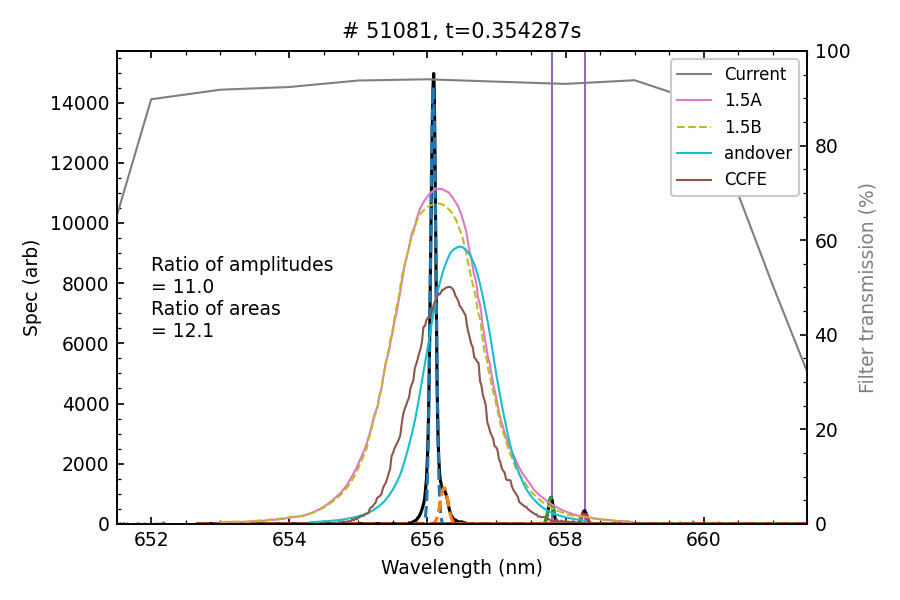

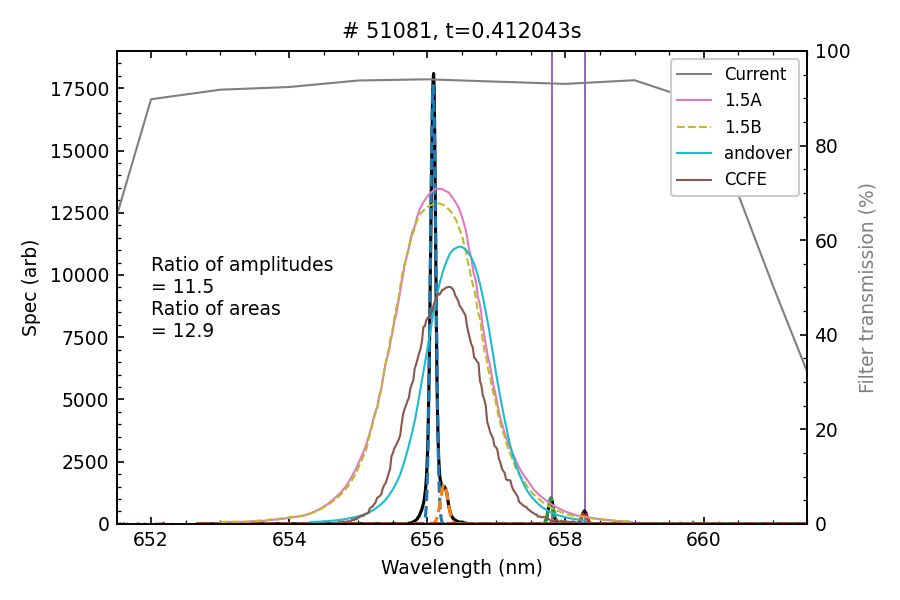

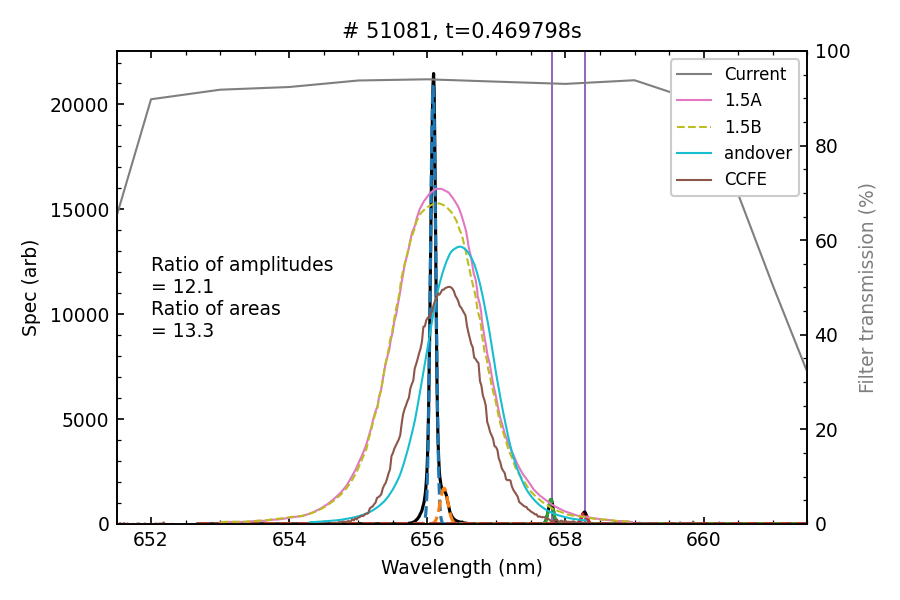

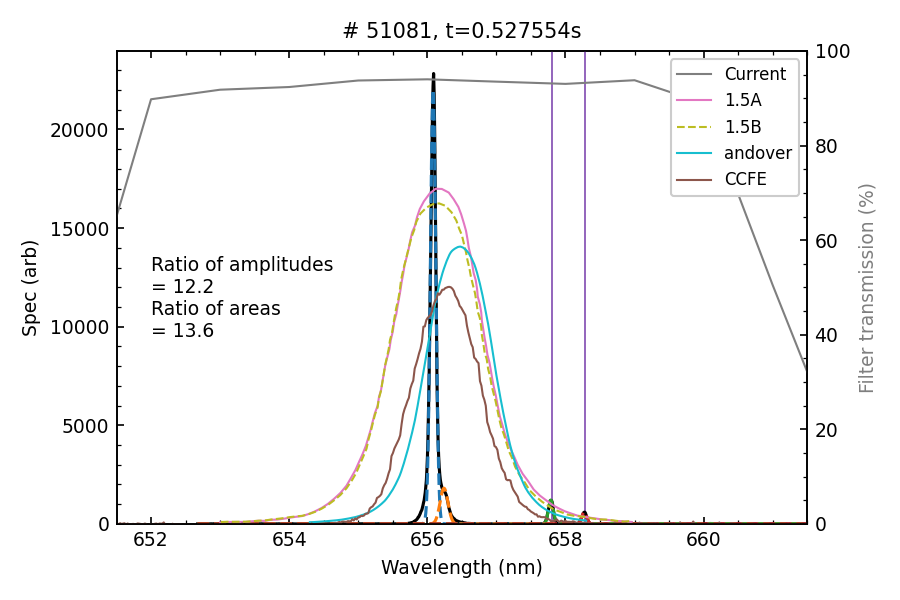

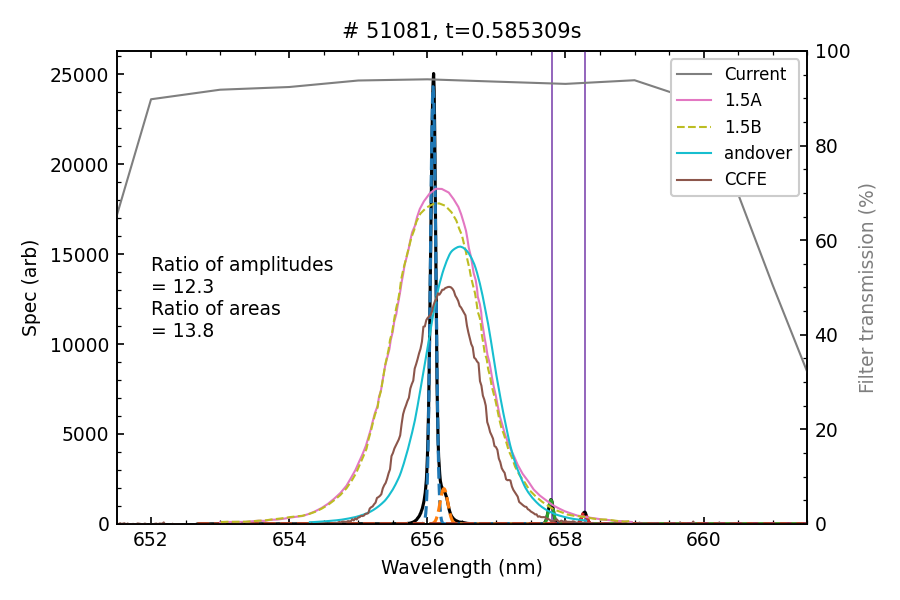

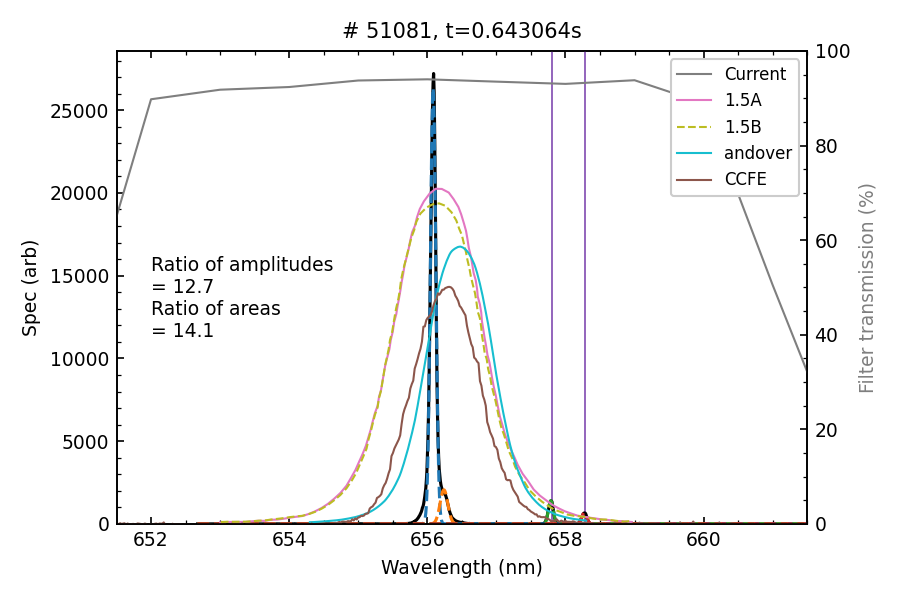

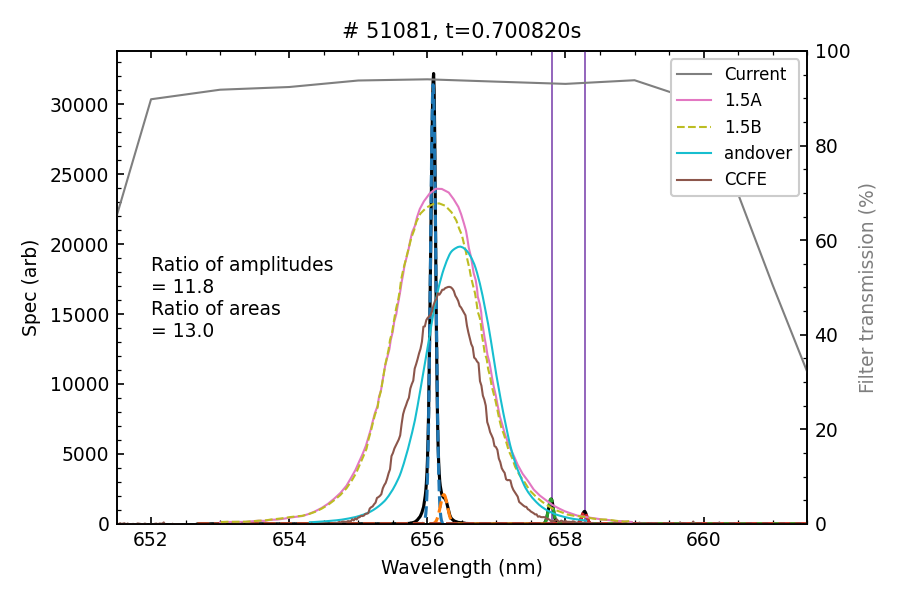

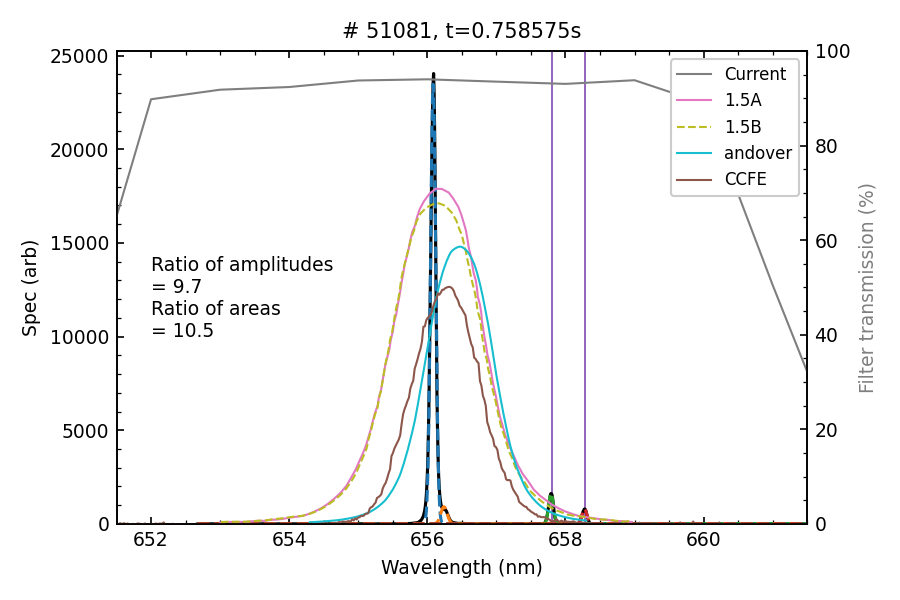

In [18]:
### select which to fit to
ch = 4 # which channel
tind0 = 3
tind1 = 15
ampRatios = np.zeros(tind1 - tind0)
areaRatios = np.zeros(tind1 - tind0)
ratio_actual = np.zeros(tind1 - tind0)
ratio_15A = np.zeros(tind1 - tind0)
ratio_15B = np.zeros(tind1 - tind0)
ratio_andover = np.zeros(tind1 - tind0)
ratio_CCFE = np.zeros(tind1 - tind0)
ratio_actual2 = np.zeros(tind1 - tind0)
ratio_15A2 = np.zeros(tind1 - tind0)
ratio_15B2 = np.zeros(tind1 - tind0)
ratio_andover2 = np.zeros(tind1 - tind0)
ratio_CCFE2 = np.zeros(tind1 - tind0)

for tind in range(tind0, tind1):
#     tind = 8 # which time
    x = wl[15:]
    y = spd[ch,tind,15:]
    y -= y[-200:].mean()

    ### fit to dalpha peaks
    I0 = findNearest(wl, 654.)
    J0 = findNearest(wl, 657.5)
    x0 = wl[I0:J0]
    y0 = spd[ch,tind,I0:J0]
    p0 = (6e5, 656.1012, 0.80, 1e5, 656.2819, 0.05)#, 600.)
    low0 = (0, 656., 0.01, 0., 656., 0.01)#, 0.)
    high0 = (7e5, 656.3, 8., 2e5, 656.4, .1)#, 1000.)
    popt0, pcov0 = curve_fit(func2, x0, y0, p0=p0, bounds=(low0,high0))
    pcov0 = np.sqrt(np.diag(pcov0))
    # print(popt0[0:3])
    # print(popt0[3:6])
    # print(popt0[6])
    # print(pcov0)


    I1 = findNearest(wl, 657.4)
    J1 = findNearest(wl, 658.8)
    x1 = wl[I1:J1]
    y1 = spd[ch,tind,I1:J1]
    # p1 = (3000., 657.8, 0.20, 1600., 658.3, 0.20, 1600., 658.0, 0.20, 1600., 658.4, 0.20, 600.)
    # low1 = (1000., 657.6, 0.05, 1000., 658.1, 0.05, 1000., 657.8, 0.05, 1000., 658.2, 0.05, 400.)
    # high1 = (3400., 658.0, 0.40, 2000., 658.5, 0.40, 2000., 658.2, 0.40, 2000., 658.6, 0.40, 800.)
    # popt1, pcov1 = curve_fit(func4, x1, y1, p0=p1, bounds=(low1,high1))
    p1 = (3000., 657.8, 0.20, 1600., 658.3, 0.20)#, 600.)
    low1 = (100., 657.6, 0.005, 100., 658.1, 0.005)#, 0.)
    high1 = (5000., 658.0, 0.40, 5000., 658.5, 0.40)#, 800.)
    popt1, pcov1 = curve_fit(func2, x1, y1, p0=p1, bounds=(low1,high1))
    pcov1 = np.sqrt(np.diag(pcov1))
    # print(popt1[0:3])
    # print(popt1[3:6])
    # print(popt1[6])
    # print(pcov1)


    # x1 = wl[J0:]
    # y1 = spd[ch,tind,J0:]

    ### some options for plotting
    filtercolour = 'k'
    filtercolour2 = 'C7'
    filterlw = 1.
    ymin = 0.
    ymax = y0.max() * 1.05
    ymax2 = 100.
    ymin2 = ymax2/ymax*ymin
    carbonlines = [657.80481,658.2876]

    ### plot it
    fig, ax = plt.subplots(1, 1, figsize=(6,4), dpi=150)
    ax2 = ax.twinx()
    ax.vlines(carbonlines, ymin, ymax, colors='C4', linewidth=0.95, zorder=3)
    ax2.plot(filter['wavelength'], filter['transmission'], '-', c='C7', lw=filterlw, zorder=2, label='Current')
    ax2.plot(filter_15A['wavelength'], filter_15A['transmission'], '-', c='C6', lw=filterlw, zorder=2, label='1.5A')
    ax2.plot(filter_15B['wavelength'], filter_15B['transmission'], '--', c='C8', lw=filterlw, zorder=2, label='1.5B')
    ax2.plot(filter_andover['wavelength'], filter_andover['transmission'], '-', c='C9', lw=filterlw, zorder=2, label='andover')
    ax2.plot(filter_CCFE['wavelength'], filter_CCFE['transmission'], '-', c='C5', lw=filterlw, zorder=2, label='CCFE')
    ax2.legend(fancybox=1, framealpha=1, loc='upper right', fontsize=8)

    ax.plot(x, y, '-k', zorder=3) # data
    ### plot the fits indivudually
    ax.plot(x, gaussian(x, popt0[0],popt0[1],popt0[2])+popt0[-1], '--', c='C0', zorder=4)
    ax.plot(x, gaussian(x, popt0[3],popt0[4],popt0[5])+popt0[-1], '--', c='C1', zorder=4)
    ax.plot(x, gaussian(x, popt1[0],popt1[1],popt1[2])+popt1[-1], '--', c='C2', zorder=4)
    ax.plot(x, gaussian(x, popt1[3],popt1[4],popt1[5])+popt1[-1], '--', c='C3', zorder=4)
    # ax.plot(x, gaussian(x, popt1[6],popt1[7],popt1[8])+popt1[-1], '--', c='C4', zorder=4)
    # ax.plot(x, gaussian(x, popt1[9],popt1[10],popt1[11])+popt1[-1], '--', c='C5', zorder=4)
    ### labels and title
    ax.set_xlabel('Wavelength (nm)', fontsize=9)
    ax.set_ylabel('Spec (arb)', fontsize=9)
    ax2.set_ylabel('Filter transmission (%)', c=filtercolour2, fontsize=9)
    ax.set_title('# {}, t={:.6f}s'.format(shotn,spt[tind]), fontsize=10)
    ### set the limits
    # ax.set_xlim(xlim)
    # ax.set_xticks(xticks)
    ax.set_ylim([ymin, ymax])
    ax2.set_ylim([ymin2,ymax2])
    ### tighten it up and save it
    ax.tick_params(
                    axis="both", which='both', labelsize=9, direction='in', 
                    left=True, bottom=True, right=False, top=True
                )
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax2.tick_params(
                    axis="both", which='both', labelsize=9, direction='in', 
                    left=False, bottom=False, right=True, top=False
                )
    ax2.yaxis.set_minor_locator(AutoMinorLocator())
    ax.set_xlim([651.5,661.5])

    # ampRatio = popt0[0] / (popt1[0] + popt1[6])
    # areaRatio = (popt0[0] * popt0[2]) / ((popt1[0] * popt1[2]) + (popt1[6] * popt1[8]))
    ampRatio = popt0[0] / (popt1[0] + popt1[3])
    ampRatios[tind-tind0] = ampRatio
    areaRatio = (popt0[0] * popt0[2]) / ((popt1[0] * popt1[2]) + (popt1[3] * popt1[5]))
    areaRatios[tind-tind0] = areaRatio

    ax.text(652., y.max()*0.5, 
            f'Ratio of amplitudes\n= {ampRatio:.1f}\nRatio of areas\n= {areaRatio:.1f}', 
            fontsize=9, ha='left', va='center')

    plt.tight_layout()
    plt.savefig(f'{shotn}/{shotn}_{spt[tind]:.6f}s.png')
    
    ###################################################################################
    
    Dalpha_actual = popt0[0] / (fHSV(popt0[1]) / 100.)
    C1_actual = popt1[0] / (fHSV(popt1[1]) / 100.)
    C2_actual = popt1[3] / (fHSV(popt1[4]) / 100.)
    ratio_actual[tind-tind0] = Dalpha_actual / (C1_actual + C2_actual)
    
    Dalpha_15A = Dalpha_actual * (f_15A(popt0[1]) / 100.)
    C1_15A = C1_actual * (f_15A(popt1[1]) / 100.)
    C2_15A = C2_actual * (f_15A(popt1[1+3]) / 100.)
    ratio_15A[tind-tind0] = Dalpha_15A / (C1_15A + C2_15A)
    
    Dalpha_15B = Dalpha_actual * (f_15B(popt0[1]) / 100.)
    C1_15B = C1_actual * (f_15B(popt1[1]) / 100.)
    C2_15B = C2_actual * (f_15B(popt1[1+3]) / 100.)
    ratio_15B[tind-tind0] = Dalpha_15B / (C1_15B + C2_15B)
    
    Dalpha_andover = Dalpha_actual * (f_andover(popt0[1]) / 100.)
    C1_andover = C1_actual * (f_andover(popt1[1]) / 100.)
    C2_andover = C2_actual * (f_andover(popt1[1+3]) / 100.)
    ratio_andover[tind-tind0] = Dalpha_andover / (C1_andover + C2_andover)
    
    Dalpha_CCFE = Dalpha_actual * (f_CCFE(popt0[1]) / 100.)
    C1_CCFE = C1_actual * (f_CCFE(popt1[1]) / 100.)
    C2_CCFE = C2_actual * (f_CCFE(popt1[1+3]) / 100.)
    print(Dalpha_CCFE, C1_CCFE, C2_CCFE)
    ratio_CCFE[tind-tind0] = Dalpha_CCFE / (C1_CCFE + C2_CCFE)
    
    Dalpha_actual2 = popt0[0] / (93.19368714285714 / 100.)
    C1_actual2 = popt1[0] / (93.19368714285714 / 100.)
    C2_actual2 = popt1[3] / (93.19368714285714 / 100.)
    ratio_actual2[tind-tind0] = Dalpha_actual2 / (C1_actual2 + C2_actual2)
    
    Dalpha_15A2 = Dalpha_actual2 * (f_15A(popt0[1]) / 100.)
    C1_15A2 = C1_actual2 * (f_15A(popt1[1]) / 100.)
    C2_15A2 = C2_actual2 * (f_15A(popt1[1+3]) / 100.)
    ratio_15A2[tind-tind0] = Dalpha_15A2 / (C1_15A2 + C2_15A2)
    
    Dalpha_15B2 = Dalpha_actual2 * (f_15B(popt0[1]) / 100.)
    C1_15B2 = C1_actual2 * (f_15B(popt1[1]) / 100.)
    C2_15B2 = C2_actual2 * (f_15B(popt1[1+3]) / 100.)
    ratio_15B2[tind-tind0] = Dalpha_15B2 / (C1_15B2 + C2_15B2)
    
    Dalpha_andover2 = Dalpha_actual2 * (f_andover(popt0[1]) / 100.)
    C1_andover2 = C1_actual2 * (f_andover(popt1[1]) / 100.)
    C2_andover2 = C2_actual2 * (f_andover(popt1[1+3]) / 100.)
    ratio_andover2[tind-tind0] = Dalpha_andover2 / (C1_andover2 + C2_andover2)
    
    Dalpha_CCFE2 = Dalpha_actual2 * (f_CCFE(popt0[1]) / 100.)
    C1_CCFE2 = C1_actual2 * (f_CCFE(popt1[1]) / 100.)
    C2_CCFE2 = C2_actual2 * (f_CCFE(popt1[1+3]) / 100.)
    ratio_CCFE2[tind-tind0] = Dalpha_CCFE2 / (C1_CCFE2 + C2_CCFE2)
    print(Dalpha_CCFE2, C1_CCFE2, C2_CCFE2)

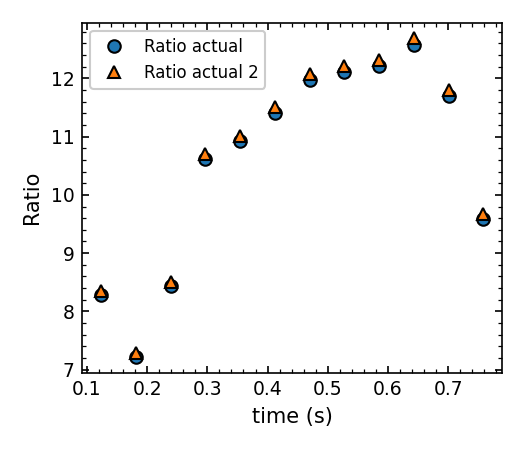

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.plot(spt[tind0:tind1], ratio_actual, 'o', c='C0', mec='k', label='Ratio actual')
ax.plot(spt[tind0:tind1], ratio_actual2, '^', c='C1', mec='k', label='Ratio actual 2')
ax.legend(fancybox=1, framealpha=1, fontsize=8)
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.set_xlabel('time (s)')
ax.set_ylabel('Ratio')
plt.tight_layout()

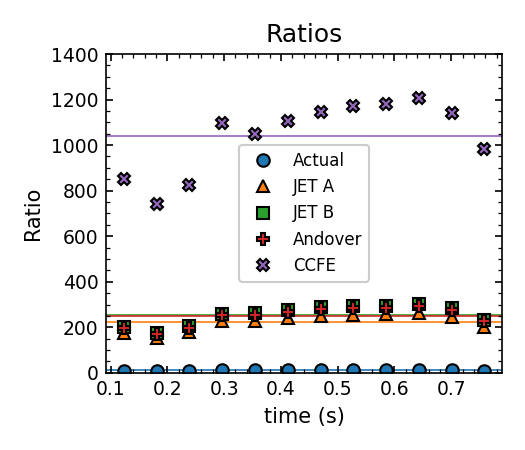

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.plot(spt[tind0:tind1], ratio_actual, 'o', c='C0', mec='k', label='Actual', zorder=2)
ax.plot(spt[tind0:tind1], ratio_15A, '^', c='C1', mec='k', label='JET A', zorder=2)
ax.plot(spt[tind0:tind1], ratio_15B, 's', c='C2', mec='k', label='JET B', zorder=2)
ax.plot(spt[tind0:tind1], ratio_andover, 'P', c='C3', mec='k', label='Andover', zorder=2)
ax.plot(spt[tind0:tind1], ratio_CCFE, 'X', c='C4', mec='k', label='CCFE', zorder=2)
ax.legend(fancybox=1, framealpha=1, fontsize=8)
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.set_xlabel('time (s)')
ax.set_ylabel('Ratio')
ax.set_title('Ratios')
xlim = ax.get_xlim()
ax.set_xlim(xlim)
ax.set_ylim([0,1400])
ax.plot(xlim, [ratio_actual.mean(),ratio_actual.mean()], '-', c='C0', lw=0.8, zorder=1)
ax.plot(xlim, [ratio_15A.mean(),ratio_15A.mean()], '-', c='C1', lw=0.8, zorder=1)
ax.plot(xlim, [ratio_15B.mean(),ratio_15B.mean()], '-', c='C2', lw=0.8, zorder=1)
ax.plot(xlim, [ratio_andover.mean(),ratio_andover.mean()], '-', c='C3', lw=0.8, zorder=1)
ax.plot(xlim, [ratio_CCFE.mean(),ratio_CCFE.mean()], '-', c='C4', lw=0.8, zorder=1)
plt.tight_layout()

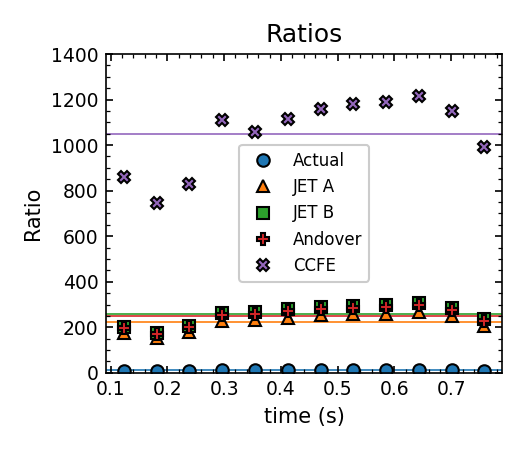

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.plot(spt[tind0:tind1], ratio_actual2, 'o', c='C0', mec='k', label='Actual')
ax.plot(spt[tind0:tind1], ratio_15A2, '^', c='C1', mec='k', label='JET A')
ax.plot(spt[tind0:tind1], ratio_15B2, 's', c='C2', mec='k', label='JET B')
ax.plot(spt[tind0:tind1], ratio_andover2, 'P', c='C3', mec='k', label='Andover')
ax.plot(spt[tind0:tind1], ratio_CCFE2, 'X', c='C4', mec='k', label='CCFE', zorder=2)
ax.legend(fancybox=1, framealpha=1, fontsize=8)
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.set_xlabel('time (s)')
ax.set_ylabel('Ratio')
ax.set_title('Ratios')
xlim = ax.get_xlim()
ax.set_xlim(xlim)
ax.set_ylim([0,1400])
ax.plot(xlim, [ratio_actual2.mean(),ratio_actual2.mean()], '-', c='C0', lw=0.8, zorder=1)
ax.plot(xlim, [ratio_15A2.mean(),ratio_15A2.mean()], '-', c='C1', lw=0.8, zorder=1)
ax.plot(xlim, [ratio_15B2.mean(),ratio_15B2.mean()], '-', c='C2', lw=0.8, zorder=1)
ax.plot(xlim, [ratio_andover2.mean(),ratio_andover2.mean()], '-', c='C3', lw=0.8, zorder=1)
ax.plot(xlim, [ratio_CCFE2.mean(),ratio_CCFE2.mean()], '-', c='C4', lw=0.8, zorder=1)
plt.tight_layout()

In [10]:
# ampRatios = np.zeros(tind1 - tind0)
# areaRatios = np.zeros(tind1 - tind0)
# ratio_actual = np.zeros(tind1 - tind0)
# ratio_15A = np.zeros(tind1 - tind0)
# ratio_15B = np.zeros(tind1 - tind0)
# ratio_andover = np.zeros(tind1 - tind0)
# ratio_actual2 = np.zeros(tind1 - tind0)
# ratio_15A2 = np.zeros(tind1 - tind0)
# ratio_15B2 = np.zeros(tind1 - tind0)
# ratio_andover2 = np.zeros(tind1 - tind0)

In [11]:
filter['wavelength'][22:29]

array([653., 654., 655., 656., 657., 658., 659.])

In [12]:
filter['transmission'][22:29].mean()

93.19368714285714

In [13]:
ratio_15A, ratio_15A2, 0.5 * (ratio_15A + ratio_15A2)

(array([175.43489399, 152.60300616, 178.31338315, 226.09693152,
        229.66416788, 240.60702942, 250.94136992, 254.70489941,
        256.94059231, 263.49393744, 246.94242764, 202.72881489]),
 array([176.96178761, 153.93124115, 179.86375389, 228.06436469,
        231.66095178, 242.69870681, 253.12390197, 256.91983445,
        259.1747003 , 265.78566727, 249.08929111, 204.49308558]),
 array([176.1983408 , 153.26712365, 179.08856852, 227.08064811,
        230.66255983, 241.65286812, 252.03263595, 255.81236693,
        258.0576463 , 264.63980235, 248.01585938, 203.61095023]))

In [14]:
ratio_15B, ratio_15B2, 0.5 * (ratio_15B + ratio_15B2)

(array([201.39753867, 175.21952952, 204.63406296, 259.38085605,
        263.69809684, 276.17101964, 288.27004339, 292.44947244,
        295.02139371, 302.70405385, 283.43109784, 232.75830307]),
 array([203.14427266, 176.73934682, 206.40718566, 261.62988552,
        265.98306354, 278.56367732, 290.76893761, 294.98410525,
        297.57800126, 305.32810615, 285.88679732, 234.77691668]),
 array([202.27090567, 175.97943817, 205.52062431, 260.50537079,
        264.84058019, 277.36734848, 289.5194905 , 293.71678884,
        296.29969749, 304.01608   , 284.65894758, 233.76760988]))

In [15]:
ratio_andover, ratio_andover2, 0.5 * (ratio_andover + ratio_andover2)

(array([196.32058491, 170.54944827, 199.00303251, 252.99675682,
        256.26133111, 268.58579926, 279.89090245, 284.2352005 ,
        286.76436815, 293.92276918, 275.76135855, 226.64947582]),
 array([198.03496165, 172.03878819, 200.73897374, 255.20575755,
        258.49654675, 270.92833813, 282.33292757, 286.71486793,
        289.26580964, 296.48723805, 278.16658306, 228.62842567]),
 array([197.17777328, 171.29411823, 199.87100313, 254.10125719,
        257.37893893, 269.75706869, 281.11191501, 285.47503421,
        288.01508889, 295.20500362, 276.9639708 , 227.63895074]))